# Python and CLI for Data Science - Session 10

- *Course*: Python and CLI for Data Science
- *Session*: 10
- *Unit*: Matplotlib Plot Types

### (Re)sources:
- [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/index.html) _by Jake VanderPlas (Code released under the MIT License)_

In [ ]:
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests


def download(name: str) -> pd.DataFrame:
    url = f"https://raw.githubusercontent.com/mwaskom/seaborn-data/master/{name}.csv"
    return pd.read_csv(io.StringIO(requests.get(url).text))

## Line Plots

- Perhaps the simplest of all plots is the visualization of a single function $y = f(x)$
- The `plot` function plots a line plot for pairwise x and y coordinates

In [ ]:
fig = plt.figure()
ax = plt.axes()

x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x))

- Under the hood, matplotlib simply draws a straight line between the coordinates
- This becomes evident if we lower the number of coordinates
- The higher the number of coordinates, the smoother the line looks

In [ ]:
fig = plt.figure()
ax = plt.axes()

x = np.linspace(0, 10, 10)
ax.plot(x, np.sin(x))
x = np.linspace(0, 10, 1000)  # reset the values for later

- You can use the `color` keyword to adjust the color of a line
- If no color is specified, Matplotlib will automatically cycle through a set of default colors for multiple lines

In [ ]:
plt.plot(x, np.sin(x - 0), color="blue")  # specify color by name
plt.plot(x, np.sin(x - 1), color="g")  # short color code (rgbcmyk)
plt.plot(x, np.sin(x - 2), color="0.75")  # grayscale between 0 and 1
plt.plot(x, np.sin(x - 3), color="#FFDD44")  # hex code (RRGGBB, 00 to FF)
plt.plot(x, np.sin(x - 4), color=(1.0, 0.2, 0.3))  # RGB tuple, values 0 to 1
plt.plot(x, np.sin(x - 5), color="chartreuse")  # HTML color names supported

- Similarly, the line style can be adjusted using the `linestyle` keyword

In [ ]:
plt.plot(x, x + 0, linestyle="solid")
plt.plot(x, x + 1, linestyle="dashed")
plt.plot(x, x + 2, linestyle="dashdot")
plt.plot(x, x + 3, linestyle="dotted")
# For short, you can use the following codes:
plt.plot(x, x + 4, linestyle="-")  # solid
plt.plot(x, x + 5, linestyle="--")  # dashed
plt.plot(x, x + 6, linestyle="-.")  # dashdot
plt.plot(x, x + 7, linestyle=":")  # dotted

- You can save some keystrokes by combining these `linestyle` and `color` codes into a single non-keyword argument to the `plt.plot` function

In [ ]:
plt.plot(x, x + 0, "-g")  # solid green
plt.plot(x, x + 1, "--c")  # dashed cyan
plt.plot(x, x + 2, "-.k")  # dashdot black
plt.plot(x, x + 3, ":r")  # dotted red

## Exercise

The dowjones dataset contains the monthly closing price of the Dow Jones index from 1914 until 1968. Plot the monthly closing price, annual average price and 5-year average price. Plot the monthly closing price first.

Then try to plot the annual and 5-year average prices by first grouping the data using `groupby` and then aggregating the data using `mean` (annual) and `rolling` (5-year average). Your plot could/should look something like this:

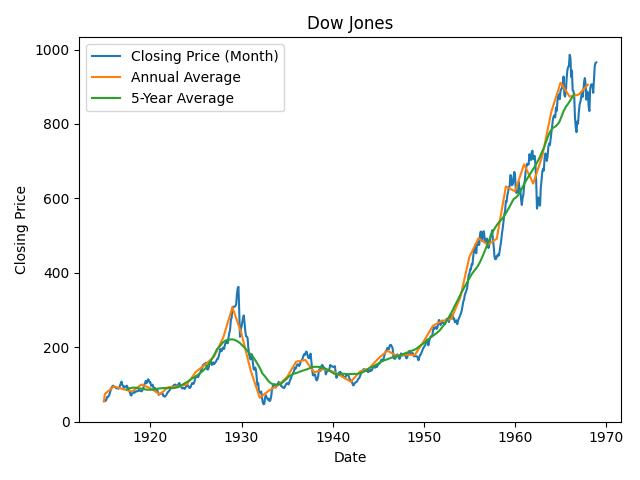

In [ ]:
dowjones = download("dowjones")
dowjones["Date"] = pd.to_datetime(dowjones["Date"])
dowjones_yearly = (
    dowjones.groupby(dowjones.groupby(dowjones["Date"].dt.year)["Date"].transform("median"))[["Price"]]
    .mean()
    .reset_index()
)
dowjones_5_year_average = pd.merge(
    dowjones[["Date"]],
    dowjones[["Price"]].rolling(12 * 5, center=True).mean(),
    left_index=True,
    right_index=True,
)
dowjones
# dowjones_yearly
# dowjones_5_year_average.dropna()

In [ ]:
# Solve the exercise here

In [ ]:
fig, ax = plt.subplots()
ax.plot(
    dowjones.loc[:, "Date"],
    dowjones.loc[:, "Price"],
    label="Closing Price (Month)",
)
ax.plot(
    dowjones_yearly.loc[:, "Date"],
    dowjones_yearly.loc[:, "Price"],
    label="Annual Average",
)
ax.plot(
    dowjones_5_year_average.loc[:, "Date"],
    dowjones_5_year_average.loc[:, "Price"],
    label="5-Year Average",
)
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")
ax.set_title("Dow Jones")
ax.legend()

## Scatter Plots

- Another commonly used plot type is the simple scatter plot, a close cousin of the line plot
- Instead of points being joined by line segments, here the points are represented individually with a dot, circle, or other shape

In [ ]:
x = np.random.randn(100)
y = np.random.randn(100)
plt.scatter(x, y, marker="o")

- `plt.scatter` can be used to create scatter plots where the properties of each individual point (size, face color, edge color, etc.) can be individually controlled or mapped to data

In [ ]:
x = np.random.randn(100)
y = np.random.randn(100)
colors = np.random.rand(100)
sizes = 1000 * np.random.rand(100)

plt.scatter(x, y, c=colors, s=sizes, alpha=0.3)
plt.colorbar();  # show color scale

## Exercise

The iris dataset contains data for 150 flowers for 3 different species. For each flower, plot the sepal length on the x-axis and the sepal width on the y-axis. Use a different color for each species. Add a legend to the plot and label the axes. Your plot could/should look something like this:

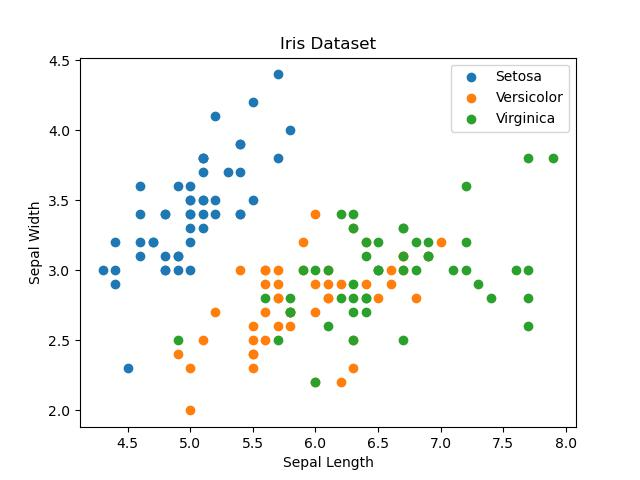

In [ ]:
iris = download("iris")
iris

In [ ]:
# Solve the exercise here

In [ ]:
fig, ax = plt.subplots()

# this plots each species in a different color but the labels cannot be set
# colors = iris.loc[:, "species"].map({"setosa": "red", "versicolor": "blue", "virginica": "green"})
# ax.scatter(iris.loc[:, "sepal_length"], iris.loc[:, "sepal_width"], c=colors)

# this plots each species separately and sets the label
for species, group in iris.groupby("species"):
    ax.scatter(group.loc[:, "sepal_length"], group.loc[:, "sepal_width"], label=species.title())
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_title("Iris Dataset")
ax.legend()

# Histograms

- A histogram combines data into discrete bins and displays the number of data points per bin as bars
- This can give a great first look into a dataset
- In matplotlib, a histogram can be created using `plt.hist`

In [ ]:
data = np.random.randn(1000)
plt.hist(data);

- The `plt.hist` docstring has more information on other available customization options
- For example, adding transparency with `alpha` is helpful when comparing histograms of several distributions

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(alpha=0.3, density=True, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs);

## Exercise

The penguins dataset contains length and weight data for 344 penguins from 3 different species. Plot the bill length of each species as a histogram. Your plot could/should look something like this.

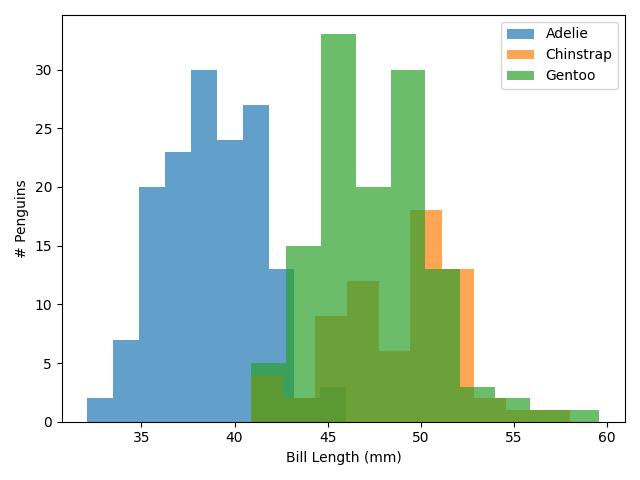

In [ ]:
penguins = download("penguins")
penguins = penguins.dropna(subset=["bill_depth_mm", "bill_length_mm"])
penguins

In [ ]:
# Solve the exercise here
fig, ax = plt.subplots()

for name, group in penguins.groupby("species"):
    ax.hist(group.loc[:, "flipper_length_mm"], label=name, alpha=0.5)
ax.legend()
# 'bill_length_mm',
#  'bill_depth_mm',
#  'flipper_length_mm',
#  'body_mass_g',

In [ ]:
fig, ax = plt.subplots()

for name, group in penguins.groupby("species"):
    ax.hist(group["bill_length_mm"], alpha=0.7, label=name)

ax.set(xlabel="Bill Length (mm)", ylabel="# Penguins")
ax.legend()

# Bar Graphs

- If data is already binned or you simply want to plot distinct values as a bar graph, you can use `plt.bar`
- The function takes a list of x values and a list of bar heights

In [ ]:
x = np.arange(9)
y = np.random.uniform(1, 3, (9,))

plt.bar(x, y)

- To add labels to the bars simply use `plt.bar_label`

In [ ]:
bars = plt.bar(x, y)
plt.bar_label(bars, fmt="{:.2f}");

- You can also provide strings instead of providing numerical x-values
- The bars are then spread equally along the x-axis and the tick labels are replaced with the strings

In [ ]:
x = [f"Group {idx}" for idx in range(9)]
bars = plt.bar(x, y)
plt.bar_label(bars, fmt="{:.2f}")
plt.xticks(rotation=60);

## Exercise

Plot the mean bill length per penguin species as a bar plot. Your plot could/should look something like this.

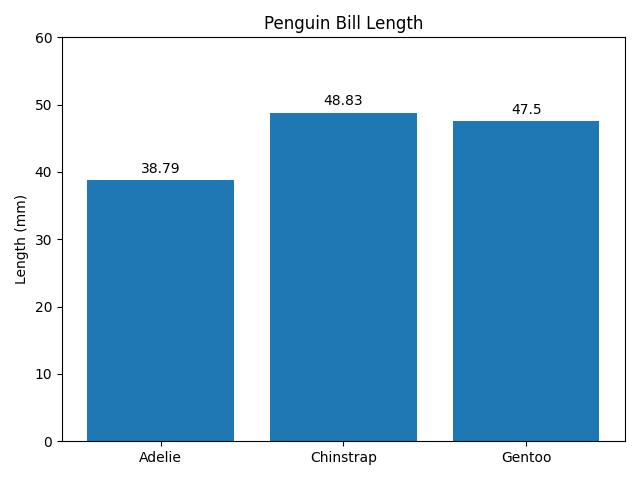

In [ ]:
# Solve the exercise here

In [ ]:
penguin_means = penguins.groupby("species")[["bill_depth_mm", "bill_length_mm", "flipper_length_mm"]].mean()
penguin_means = penguin_means.round(2)
penguin_means = penguin_means.rename(lambda x: " ".join(x.split("_")[:2]).title(), axis=1)

fig, ax = plt.subplots()

measurement = "Bill Length"

rects = ax.bar(penguin_means.index, penguin_means[measurement])
ax.bar_label(rects, padding=3)

ax.set(ylabel="Length (mm)", title=f"Penguin {measurement}", ylim=(0, 60))

# Pie Charts

- The pie chart is the go-to option for visualizing proportions
- Matplotlib allows plotting pie charts using `plt.pie`

- The function takes a list of values indicating the wedge sizes
- The values do not need to provided as percentages
- The function automatically normalizes the values to determine the proportion of each wedge

In [ ]:
plt.pie(np.arange(4) + 1);

- The plotting function provides several convenience options to, for example, add percentages or labels per wedge

In [ ]:
plt.pie(np.arange(4) + 1, autopct="%1.1f%%", labels=[f"Group {idx}" for idx in range(4)]);

# Exercise

The titanic dataset contains data about the passengers of the titanic and whether they survived or not. For each ticket class, plot the percentages of whether the passengers from that class survived or perished. Your plots could/should look something like this.

**You should plot each plot individually.** We will take a look at subplots and subfigures later.

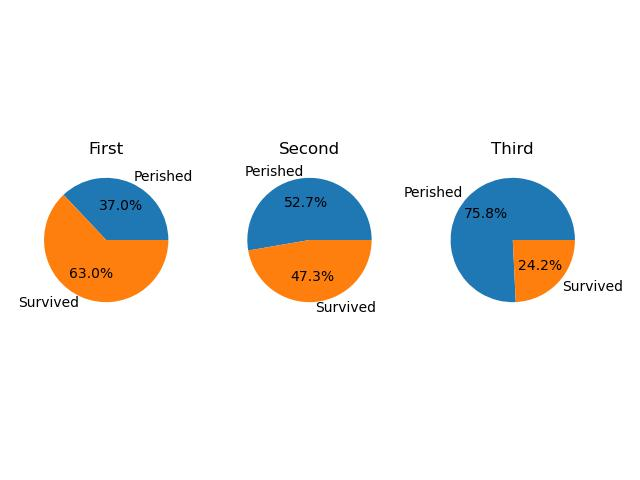

In [ ]:
titanic = download("titanic")
titanic

In [ ]:
# Solve the exercise here

In [ ]:
c = "Third"
df = titanic.loc[titanic["class"] == c].groupby("survived").size()
df = df.rename({1: "Survived", 0: "Perished"})

fig, ax = plt.subplots()

ax.pie(df, labels=df.index, autopct="%1.1f%%")
ax.set_title(c)